In [1]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets 
import evaluate
import random

## Preprocess our data

In [2]:
# data should be saved in a folder called 'emotions_data' which is saved in the same place as your notebook
data_train = pd.read_csv('./emotions_data/emotion-labels-train.csv') 
data_test = pd.read_csv('./emotions_data/emotion-labels-test.csv')
data_val = pd.read_csv('./emotions_data/emotion-labels-val.csv')


In [3]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [4]:
# Combines three separate datasets (train, test, validation) into a single DataFrame. 
# ignore_index=True resets the row numbers so they run continuously from 0 instead of overlapping.
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [5]:
# Creates a new column text_clean by running each row in the text column through the clean() function from cleantext. 
# no_emoji=True strips out all emojis from the text.
data['text_clean'] = data['text'].apply(lambda x: clean(x, no_emoji=True))

In [6]:
# Updates text_clean by removing all Twitter/social media mentions like @username from each row. 
# The regex @[^\s]+ matches @ followed by any non-space characters.
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^\s]+', '', x))

In [7]:
# Displays the first 20 rows of the DataFrame so you can visually verify the cleaning worked correctly.
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #fr...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": thank you so much, gloria! you're so sweet,..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"today i reached 1000 subscribers on yt!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"good morning, love! happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#bridgetjonesbaby is the best thing i've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
9,@IndyMN I thought the holidays could not get a...,joy,i thought the holidays could not get any more...


In [8]:
print(data_train.columns.tolist())
print(data_test.columns.tolist())
print(data_val.columns.tolist())

['text', 'label']
['text', 'label']
['text', 'label']


<Axes: xlabel='label'>

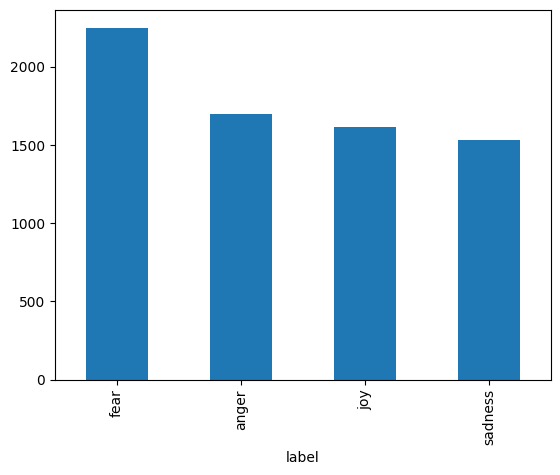

In [9]:
# This creates a bar chart showing the distribution of labels in your dataset. Here's what each part does:
# .data['label'] — selects the label column from your DataFrame
# .value_counts() — counts how many times each label appears (e.g. positive: 4000, negative: 3500, neutral: 2000)
# .plot(kind="bar") — plots those counts as a bar chart
# It's a quick way to check if your dataset is balanced or imbalanced across classes — an important thing to know before training a model.
data['label'].value_counts().plot(kind="bar")

In [10]:
# The following is called undersampling. It prevents the model from being biased toward the majority class by trimming all classes down to match 
# the smallest one. After these two lines, every label will have exactly the same number of rows.
# These two lines balance the dataset so every label has the same number of samples. Here's the breakdown:
# Line 1:
# data.groupby('label') — groups the DataFrame by label (e.g. positive, negative, neutral)
# Line 2:
# g.size().min() — finds the smallest class size (e.g. if positive=4000, negative=3500, neutral=2000, this returns 2000)
# x.sample(g.size().min()) — randomly samples that many rows from each group, so all classes end up with the same count
# reset_index(drop=True) — resets row numbers cleanly
# pd.DataFrame(...) — wraps the result back into a DataFrame 
# g = data.groupby('label')
# data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))
min_count = data['label'].value_counts().min()
data = pd.concat([
    data[data['label'] == label].sample(min_count) 
    for label in data['label'].unique()
]).reset_index(drop=True)
# list all columns labels
print(data.columns.tolist())

['text', 'label', 'text_clean']


<Axes: xlabel='label'>

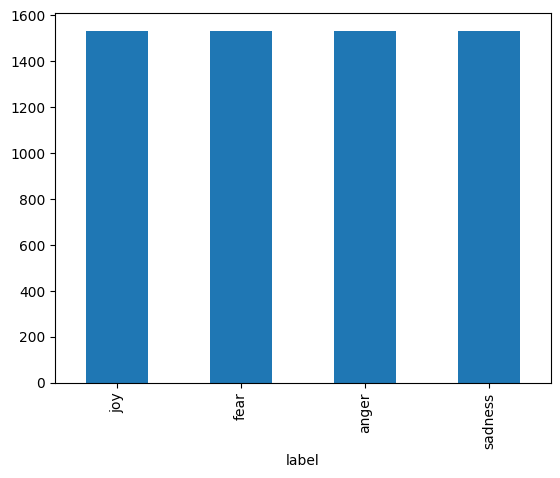

In [11]:
# Same line as before — but now it serves as a verification step.
# After the undersampling you just did, this bar chart should now show all labels with equal height bars, confirming that the balancing worked correctly.
# Compare it to the first bar chart you plotted earlier — that one likely showed uneven bars, while this one should look uniform across all classes.
data['label'].value_counts().plot(kind="bar")

In [12]:
# This creates a new column label_int that converts text labels into numbers. For example:
# "negative" → 0
# "neutral" → 1
# "positive" → 2
# Here's the breakdown:
# LabelEncoder() — creates a label encoder object from scikit-learn
# .fit_transform(data['label']) — learns the unique labels and immediately converts them to integers in one step
# data['label_int'] — stores the numeric result as a new column

# Why this is needed — machine learning models can't work with raw text labels like "positive" or "negative". 
# They require numbers. This numeric column will be used as the target variable during model training.
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [13]:
# train_test_split is called twice to create three dataset splits:
#
# Line 1: Split full dataset
#   - 80% → train_split (training + validation)
#   - 20% → test_split  (final evaluation, untouched during training)
#
# Line 2: Split train_split further
#   - 90% of train_split → train_split (model learns from this)
#   - 10% of train_split → val_split   (monitors performance, catches overfitting)
#
# Final proportions of original dataset:
#   - Train      : 72%  (0.8 × 0.9)
#   - Validation :  8%  (0.8 × 0.1)
#   - Test       : 20%
#
# Why three splits?
#   - Train      : model learns patterns from this data
#   - Validation : used during training to tune and monitor for overfitting
#   - Test       : final unbiased evaluation after training is complete

train_split, test_split = train_test_split(data, train_size=0.8)
train_split, val_split  = train_test_split(train_split, train_size=0.9)

In [14]:
# Verify the split sizes after train_test_split:
#
# Total rows = 6132 (4414 + 1227 + 491)
#
# Split      | Actual | Expected % | Actual %
# -----------+--------+------------+---------
# Train      |  4414  |    72%     |  71.9% ✅
# Test       |  1227  |    20%     |  20.0% ✅
# Validation |   491  |     8%     |   8.0% ✅
#
# Splits landed exactly where expected.
# Dataset is correctly divided and ready for model training.

print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [15]:
# Create clean DataFrames for each split, keeping only the two columns
# needed for model training: numeric label and cleaned text.
#
# train_df and test_df each contain:
#   - "label" : integer-encoded labels (from label_int column)
#   - "text"  : cleaned text (from text_clean column)
#
# .values converts each column to a NumPy array before loading
# into the new DataFrame — ensures clean indexing with no carry-over
# from the original split indices.

train_df = pd.DataFrame({
    "label": train_split.label_int.values,
    "text": train_split.text_clean.values
})
test_df = pd.DataFrame({
    "label": test_split.label_int.values,
    "text": test_split.text_clean.values
})

In [16]:
# Convert pandas DataFrames into HuggingFace Dataset objects.
#
# HuggingFace's Trainer requires data in Dataset format, not pandas DataFrames.
# datasets.Dataset.from_dict() performs this conversion.
#
# Benefits of HuggingFace Dataset format over pandas DataFrame:
#   - Compatible with HuggingFace Trainer and tokenizer .map() function
#   - Memory efficient — supports Arrow format for large datasets
#   - Built-in batching and shuffling during training

train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [17]:
# Combine train and test Dataset objects into a single DatasetDict.
#
# DatasetDict is a dictionary-like container that holds multiple
# dataset splits under named keys:
#   - "train" : training data (4414 rows)
#   - "test"  : test data    (1227 rows)
#
# Benefits of DatasetDict:
#   - Single object to pass around instead of separate variables
#   - HuggingFace Trainer can directly access splits by name
#   - Enables consistent tokenization across all splits in one .map() call

dataset_dict = datasets.DatasetDict({"train": train_df, "test": test_df})

In [18]:
# Calling dataset_dict without print() or any method simply displays
# a summary of the DatasetDict in Jupyter — showing:
#   - Split names  : train, test
#   - Number of rows per split
#   - Column names and their data types (features)
#
# Example output:
# DatasetDict({
#     train: Dataset({
#         features: ['label', 'text'],
#         num_rows: 4414
#     })
#     test: Dataset({
#         features: ['label', 'text'],
#         num_rows: 1227
#     })
# })
#
# Useful as a quick sanity check before moving on to tokenization.

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

## Create embeddings - Dataset Tokenization

In [19]:
# ─── Environment & Authentication Setup ───────────────────────────────────────

# Print the active Python executable path to confirm the correct
# conda environment (llms_course_env_311) is being used as the kernel.
import sys
print(sys.executable)

# Load HF_TOKEN from the .env file via config.py to authenticate
# with HuggingFace Hub. This avoids the following warning:
#   "You are sending unauthenticated requests to the HF Hub.
#    Please set a HF_TOKEN to enable higher rate limits and faster downloads."
#
# Benefits of authenticating with HF_TOKEN:
#   - Eliminates unauthenticated request warnings
#   - Higher rate limits for downloading models and datasets
#   - Faster downloads
#   - Access to gated/private models if permitted
#
# load_dotenv() reads the .env file and loads its variables
# into the environment so os.getenv() and config.py can access them.
import os
from dotenv import load_dotenv
load_dotenv()

import config

# Verify the token loaded correctly before proceeding.
if config.HF_TOKEN:
    print("Huggingface (xlnet) TOKEN loaded successfully")
else:
    print("Huggingface TOKEN not found")

# Assign the token to a local variable and set it explicitly
# in os.environ so HuggingFace libraries can detect it automatically
# during model downloads and API calls.
my_hf_token = config.HF_TOKEN
os.environ["HF_TOKEN"] = my_hf_token

C:\Tools\anaconda3\envs\llms_course_env_311\python.exe
Huggingface (xlnet) TOKEN loaded successfully


In [20]:
# Load the XLNetTokenizer for the "xlnet-base-cased" pretrained model.
#
# XLNetTokenizer is specific to XLNet architecture and uses
# SentencePiece tokenization (different from BERT's WordPiece).
#
# "xlnet-base-cased" means:
#   - base    : smaller version (vs xlnet-large)
#   - cased   : preserves uppercase/lowercase distinction
#               (important for sentiment analysis where casing can carry meaning)
#
# If not already cached locally, this will download the tokenizer
# vocabulary files from HuggingFace Hub automatically.
# Subsequent runs will load instantly from cache.

tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [21]:
# Define a tokenization function to be applied across the entire dataset.
#
# Parameters:
#   - examples["text"]   : the cleaned text column from each row
#   - padding="max_length": pads shorter sequences with zeros up to max_length
#                           so all sequences are the same length (required for batching)
#   - max_length=128     : sets the maximum token length per sequence
#                           sequences longer than 128 tokens will be truncated
#                           sequences shorter than 128 tokens will be padded
#   - truncation=True    : enables truncation for sequences exceeding max_length
#
# Why max_length=128?
#   - XLNet can handle up to 512 tokens but 128 is a common choice for
#     short texts like tweets/reviews — balances speed vs context
#   - Shorter sequences = faster training on CPU
#
# This function is not called directly — it will be passed to
# dataset.map() in the next step to tokenize all rows efficiently.
def tokenize_function(examples):
    return tokenizer(examples["text"], padding = "max_length", max_length = 128, truncation=True)

In [22]:
# Apply the tokenize_function across the entire DatasetDict in batches.
#
# .map() iterates over all splits (train, test) and applies
# tokenize_function to each row, adding new columns to the dataset:
#   - "input_ids"      : token IDs representing each word/subword
#   - "attention_mask" : 1 for real tokens, 0 for padding tokens
#   - "token_type_ids" : segment IDs (used for sentence pairs)
#
# batched=True:
#   - Processes multiple rows at once instead of one at a time
#   - Significantly faster than row-by-row processing
#   - Recommended default for all .map() tokenization calls
#
# Result: tokenized_datasets is a DatasetDict with the same
# train/test splits but now enriched with tokenized columns,
# ready to be fed directly into the XLNet model for training.

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [23]:
# Display a summary of the tokenized DatasetDict in Jupyter.
#
# After tokenization, the dataset now has additional columns
# compared to the original dataset_dict. Expected output:
#
# DatasetDict({
#     train: Dataset({
#         features: ['label', 'text', 'input_ids', 'attention_mask', 'token_type_ids'],
#         num_rows: 4414
#     })
#     test: Dataset({
#         features: ['label', 'text', 'input_ids', 'attention_mask', 'token_type_ids'],
#         num_rows: 1227
#     })
# })
#
# Key difference from earlier dataset_dict display:
#   - Before : only 'label' and 'text' columns
#   - After  : added 'input_ids', 'attention_mask', 'token_type_ids'
#
# Quick sanity check before moving on to model training.

tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [24]:
# Print the first cleaned text sample from the training split.
#
# Breakdown:
#   - tokenized_datasets['train'] : accesses the train split
#   - ['text']                    : selects the text column
#   - [0]                         : retrieves the first row (index 0)
#
# Purpose: quick sanity check to visually inspect what a raw
# cleaned text sample looks like before it was tokenized —
# confirming emojis and @mentions were properly removed
# by the earlier cleaning steps.

print(tokenized_datasets['train']['text'][0])

 just die depression.


In [25]:
# Print the tokenized input_ids for the first training sample.
#
# input_ids is a list of 128 integers where:
#   - Each integer maps to a token in XLNet's vocabulary
#   - Real tokens occupy the front of the list
#   - Padding tokens (value: 5) fill the remaining positions up to 128
#
# Comparing with the previous cell:
#   - Previous cell showed the human-readable cleaned text
#   - This cell shows the same text converted to numbers the model sees
#
# Example output (truncated):
#   [34, 679, 18, 4848, 23, 17, ... 5, 5, 5, 5]
#                                   ^^^^^^^^^^^
#                                   padding tokens at the end
#
# Always length 128 due to padding="max_length" set in tokenize_function.

print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 125, 2734, 6185, 9, 4, 3]


In [ ]:
# Decode token ID 5 back into its human-readable text representation.
#
# tokenizer.decode() is the reverse of tokenization —
# it converts a numeric token ID back to its original string.
#
# In this case, decoding ID 5 reveals what the padding token looks like,
# confirming what value XLNetTokenizer uses for padding.
#
# Expected output: "<pad>"
#
# This connects back to the previous cell — the repeated 5s at the
# end of input_ids are confirmed to be <pad> tokens, filling the
# sequence up to max_length=128.
tokenizer.decode(5)

In [26]:
# Print the features (column names and their data types) of the
# tokenized training dataset.
#
# Expected output:
#   {
#     'label':         Value(dtype='int64'),
#     'text':          Value(dtype='string'),
#     'input_ids':     Sequence(feature=Value(dtype='int32'), length=128),
#     'attention_mask':Sequence(feature=Value(dtype='int8'),  length=128),
#     'token_type_ids':Sequence(feature=Value(dtype='int8'),  length=128)
#   }
#
# Purpose: sanity check before training to confirm:
#   - All tokenization columns were added successfully
#   - Data types are correct for model input
#   - Sequence lengths are 128 as set in tokenize_function
#
# The 'label' column is what the model will learn to predict.
# The 'input_ids', 'attention_mask', 'token_type_ids' columns
# are the inputs the model receives during training.

print(tokenized_datasets['train'].features)

{'label': Value('int64'), 'text': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [27]:
# Print the token_type_ids for the first training sample.
#
# token_type_ids distinguishes between different segments in a sequence.
# Since we are feeding single sentences (not sentence pairs), expected output:
#
#   [0, 0, 0, 0, ... 0, 0, 0]  ← all zeros, length 128
#
# Token type ID values for XLNet:
#   - 0 : belongs to the main text sequence
#   - 1 : would be used for a second sequence (e.g. question/answer pairs)
#   - 2 : padding tokens
#
# Note: XLNet's token_type_ids differ slightly from BERT's —
# XLNet uses 2 for padding positions rather than 0,
# so you may see a mix of 0s and 2s in the output:
#   [0, 0, 0, 0, ... 2, 2, 2]
#                    ^^^^^^^^
#                    padding positions

if 'token_type_ids' in tokenized_datasets['train'].features:
    print(tokenized_datasets['train']['token_type_ids'][0])
else:
    print("token_type_ids not present for this model")

token_type_ids not present for this model


In [28]:
# Print the attention_mask for the first training sample.
#
# attention_mask tells the model which tokens to pay attention to
# and which to ignore during training.
#
# Values:
#   - 1 : real token — model should attend to this
#   - 0 : padding token — model should ignore this
#
# Expected output (length 128):
#   [1, 1, 1, 1, ... 1, 0, 0, 0]
#                    ^^^^^^^^^^^
#                    padding positions masked out
#
# Connecting all three token outputs together:
#   - input_ids      : the actual token values (real tokens + 5s for padding)
#   - token_type_ids : segment identifiers (0s for text, 2s for padding)
#   - attention_mask : what the model focuses on (1s for real, 0s for padding)
#
# The number of 1s in attention_mask tells you the actual length
# of the text before padding was applied.

print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


In [29]:
# Create small subsets of train and test datasets for quick experimentation.
#
# .shuffle(seed=42):
#   - Randomly shuffles the dataset before selecting rows
#   - seed=42 ensures reproducibility — same rows selected every run
#   - Without a seed, different rows would be picked each time
#
# .select(range(100)):
#   - Picks the first 100 rows after shuffling
#   - Results in a 100-row subset instead of the full dataset
#
# Why create small subsets?
#   - Training XLNet on the full dataset (4414 rows) on CPU would take
#     a very long time — potentially hours
#   - 100 rows allows you to verify the training pipeline works correctly
#     in minutes before committing to a full training run
#   - Common practice during development/experimentation phase
#
# Result:
#   - small_train_dataset : 100 randomly selected training samples
#   - small_eval_dataset  : 100 randomly selected test samples

small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

## Fine tune our model

In [30]:
# sets a constant that stores the number of unique classes in your dataset 
# It tells the model how many output neurons to create in its final classification layer — one per label. 
# Using a named constant like NUM_LABELS is good practice since you only need to change it in one place if your dataset changes.
NUM_LABELS = 4

In [31]:
# Load XLNet model pretrained on "xlnet-base-cased" and configure it
# for sequence classification (sentiment/emotion detection).
#
# from_pretrained('xlnet-base-cased'):
#   - Loads the base XLNet model weights from HuggingFace Hub (or local cache)
#   - "cased" preserves uppercase/lowercase which matters for emotion detection
#
# num_labels=NUM_LABELS (4):
#   - Replaces the default classification head with one that has 4 output neurons
#   - One neuron per emotion class
#
# id2label mapping:
#   - 0 → 'anger'
#   - 1 → 'fear'
#   - 2 → 'joy'
#   - 3 → 'sadness'
#   - Maps numeric predictions back to human-readable emotion labels
#   - Used automatically when running inference via pipeline()
#
# Note: The classification head weights are randomly initialized —
# only the base XLNet weights are pretrained. The model must be
# fine-tuned on your emotion dataset before it can make
# meaningful predictions.

# model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased',
#                                                         num_labels=NUM_LABELS,
#                                                         id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'})

# by adding following param in above function call, the following warnings can be ignored. 
# ignore_mismatched_sizes=True

# refactored above code
# --- labels ---
id2label = {0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}
label2id = {v: k for k, v in id2label.items()}
# --- model ---
model = XLNetForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
# --- metric ---
metric = evaluate.load("accuracy")

In [33]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return metric.compute(predictions=predictions, references=labels)
# refactored code
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return metric.compute(predictions=preds, references=labels)

In [34]:
# training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)
# Refactored to
# --- training args ---
training_args = TrainingArguments(
    output_dir="test_trainer",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [35]:
# trainer = Trainer(
#     model=model, 
#     args=training_args,
#     train_dataset=small_train_dataset,
#     eval_dataset=small_eval_dataset,
#     compute_metrics=compute_metrics)
# Refactored
# --- trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics
)

In [36]:
trainer.train()

C:\Tools\anaconda3\envs\llms_course_env_311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.469318,1.391852,0.250000
2,1.380474,1.360470,0.370000
3,1.283736,1.394480,0.380000
4,1.144432,1.336716,0.390000
5,1.121288,1.352118,0.420000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Tools\anaconda3\envs\llms_course_env_311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

C:\Tools\anaconda3\envs\llms_course_env_311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Tools\anaconda3\envs\llms_course_env_311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=65, training_loss=1.2798493165236253, metrics={'train_runtime': 362.224, 'train_samples_per_second': 1.38, 'train_steps_per_second': 0.179, 'total_flos': 35610625536000.0, 'train_loss': 1.2798493165236253, 'epoch': 5.0})

## Evaluate model

In [37]:
# Run evaluation on the test dataset using the trained model.
# Returns metrics such as eval_loss, eval_accuracy, eval_runtime,
# and eval_samples_per_second.
# Uses small_eval_dataset (100 rows) as defined in TrainingArguments.
trainer.evaluate()

C:\Tools\anaconda3\envs\llms_course_env_311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.352117896080017,
 'eval_accuracy': 0.42,
 'eval_runtime': 12.3047,
 'eval_samples_per_second': 8.127,
 'eval_steps_per_second': 1.057,
 'epoch': 5.0}

In [38]:
# Save the fine-tuned model weights and configuration to a local
# directory called "fine_tuned_model".
# Creates the folder if it doesn't exist and saves:
#   - model weights (model.safetensors)
#   - model config (config.json)
#   - tokenizer files
# Allows reloading the model later without retraining.
model.save_pretrained("fine_tuned_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
# Reload the fine-tuned model from the local "fine_tuned_model" directory.
# This confirms the saved model loads correctly and is ready for inference.
# Avoids retraining from scratch in future sessions.
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [40]:
# Create a text classification pipeline using the fine-tuned model
# and tokenizer for easy inference on new text samples.
# pipeline() handles tokenization and prediction in a single call.
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

In [41]:
# Test the classifier on a random sample from the validation set.
#
# random.randint(0, len(val_split)) : picks a random row index
# val_split['text_clean'][rand_int] : retrieves the cleaned text at that index
# clf(..., top_k=None)              : returns scores for ALL emotion labels
#                                     instead of just the top prediction
# print(answer)                     : displays the full prediction results
#
# Example output:
#   [{'label': 'joy',     'score': 0.85},
#    {'label': 'anger',   'score': 0.06},
#    {'label': 'fear',    'score': 0.05},
#    {'label': 'sadness', 'score': 0.04}]
rand_int = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_int])
answer = clf(val_split['text_clean'][rand_int], top_k=None)
print(answer)

 i keep a down vest or sweater in my pack year round! helps on chilly mornings or breezy mountain tops! #mysportinglife
[{'label': 'fear', 'score': 0.4410722255706787}, {'label': 'sadness', 'score': 0.1994425654411316}, {'label': 'joy', 'score': 0.19330620765686035}, {'label': 'anger', 'score': 0.16617904603481293}]
